On a un pb de régression

modèles à essayer : régression linéaire, KNN, forets aléatoires, xgboost, réseaux de neuronnes
(notamment des RNN car séries temporelles)

mélangent de modèles ? 


QUESTIONNEMENT : 

- prédire les deux sorties à la fois ou les deux séparément ?
La question se pose surtout
pour les réseaux de neuronnes : des études ont montré que dans certains cas (je me rappelle plus lesquels)
cela améliore la performance car cela oblige le réseau de neuronnes à comprendre dans la profondeur les
données

- Quel retard choisir ?? 
Peut être choisir par validation croisée ? 

- peu de données ... 1000 observations --> attention au surapprentissage 








On importe les modules et packages nécessaires pour le on fonctionnement du code (peut être faire un 
requirements.txt puis pip install -r requirements.txt)

In [4]:
#%pip install scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

chargement des données et première exploration des données

['Utr', 'Ytr', 'Uts1', 'Uts2']
Utr shape: (1000, 2)
Ytr shape: (1000, 2)
Uts shape: (1000, 2)
Uts2 shape: (1000, 2)
       Utr0      Utr1
0  1.225856  0.043213
1 -0.379083 -0.411898
2  0.683140 -0.921644
3  0.374853 -0.572683
4  0.256665 -0.760764
       Ytr0      Ytr1
0  0.000000  0.000000
1  0.042170  0.720120
2 -0.016521 -0.222306
3 -0.235810  0.020866
4 -0.080339 -0.352666


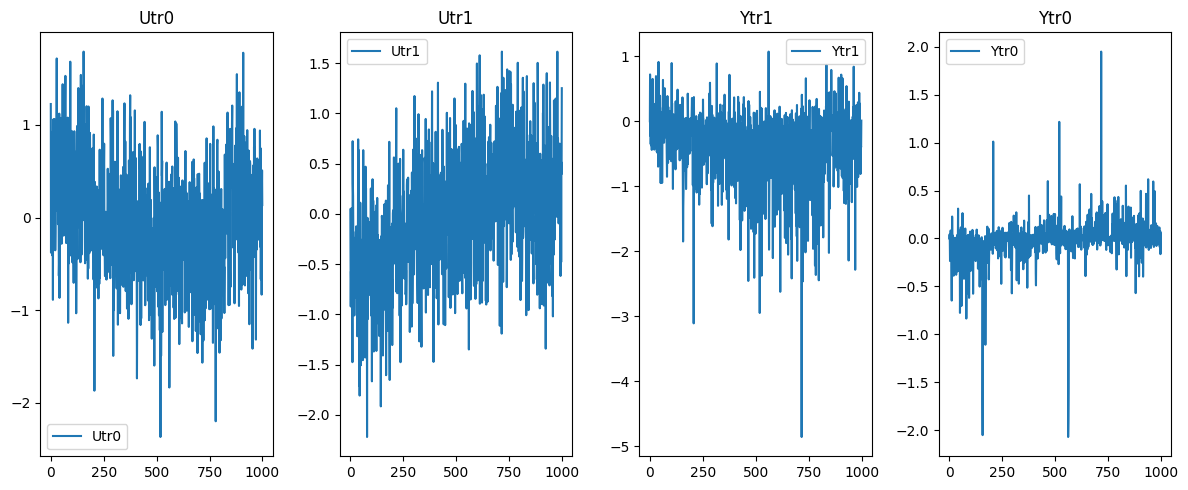

In [5]:
# Charger le fichier
data = np.load('StudentdataNARX.npz')

# Voir la liste des variables
print(data.files)

Utr = data['Utr']
Ytr = data['Ytr']
Uts = data['Uts1']
Uts2 = data['Uts2']

print("Utr shape:", Utr.shape)
print("Ytr shape:", Ytr.shape)
print("Uts shape:", Uts.shape)
print("Uts2 shape:", Uts2.shape)



# transformer les données de train en dataframe pandas
X = pd.DataFrame(Utr, columns=[f'Utr{i}' for i in range(Utr.shape[1])])
Y = pd.DataFrame(Ytr, columns=[f'Ytr{i}' for i in range(Ytr.shape[1])])
print(X.head(5))
print(Y.head(5))



figure, axes = plt.subplots(1, 4, figsize=(12, 5))
axes[0].plot(X['Utr0'], label='Utr0')
axes[0].set_title('Utr0')
axes[0].legend()
axes[1].plot(X['Utr1'], label='Utr1')
axes[1].set_title('Utr1')
axes[1].legend()
axes[2].plot(Y['Ytr1'], label='Ytr1')
axes[2].set_title('Ytr1')
axes[2].legend()
axes[3].plot(Y['Ytr0'], label='Ytr0')
axes[3].set_title('Ytr0')
axes[3].legend()
plt.tight_layout()
plt.show()


- Création des pilotes

**PILOTE NARX1**

          u
0  0.000000
1  0.993428
2 -0.276529
3  1.295377
4  3.046060
shape U (1001, 1)
         y1        y2
0  0.000000  0.000000
1  0.000000  0.198686
2  0.495410 -0.055306
3 -0.038893  0.734467
4  1.031152  0.818033
5  2.010854  0.744784
6  0.946337  1.326648
7  1.202253  2.448392
8  2.249854  1.712996
9  2.674563  1.191502
shape Y (1000, 2)
shape U (1000, 1)


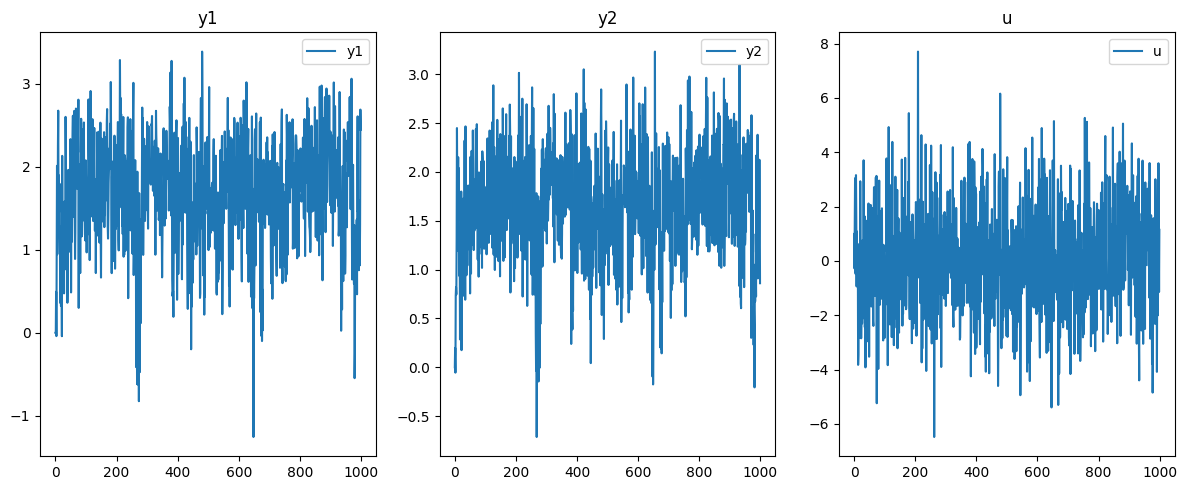

In [6]:

#simule NARX1 en pouvant choisir longueur (N) et variance du bruit
# dois etre mis en fonction car demande d'être flexible 
def simulate_Narx1(n_points,sigma_noise,seed=42): 

    np.random.seed(seed) # pour la reproductibilité
    
    # création des pilotes donnés dans l'énoncé
    # génération de U
    U_Narx1 = pd.DataFrame(np.zeros((n_points+1,1)),columns=['u']) #permet d'ajouter instant zéro pour y(0)=u(0)=0
    Y_Narx1 = pd.DataFrame(np.zeros((n_points+1,2)),columns=['y1', 'y2'])
   
    # générer U qui suit une distribution normale (moyenne 0, écart-type 2) : mon choix arbitraire
    U_Narx1.loc[1:,'u'] = np.random.normal(0, 2, size=n_points) #évite 4 lignes en plus
    # n+1 points car on a u-1 qui doit être défini pour générer y1_1 et y2_1 :
    # on change sa valeur en 0 après
    #U_Narx1.loc[0, 'u'] = 0 # pour respecter l'énoncé =u-1 = 0
    #U_Narx1.loc[1, 'u'] = 0 # u0 = 0

    print(U_Narx1.head())
    print("shape U", U_Narx1.shape)


    # génération de Y
    # y1_0 = 0, y2_0 = 0 # cf énoncé : je me mets dans le m^me cas que les données réelles
    # à prédire (exo principal du projet)
    y1_0 = 0
    y2_0 = 0
    # y-1 = 0, y-2 = 0 # cf énoncé, nécessaire pour générer y1_1 et y2_1
    y1_minus_1 = 0
    y2_minus_1 = 0
    Y_Narx1.loc[0] = [y1_minus_1, y2_minus_1]
    Y_Narx1.loc[1] = [y1_0, y2_0]

    for i in range(1, n_points+1): # on est décalé à 2 car on a ajouter y-1
        
        # les indices seront réglés après la boucle
        y1_k1= Y_Narx1['y1'].iloc[i-2] if i-2>=0 else 0 #car iloc def de 0 à length-1 donc quand -1 pas bon 
        y2_k1= Y_Narx1['y2'].iloc[i-2] if i-2>=0 else 0
        u_k1=U_Narx1['u'].iloc[i-2] if i-2>=0 else 0

        # deux formules données dans l'énoncé
        y1_i = 0.5 * y2_k1 + np.sin(Y_Narx1['y2'].iloc[i-1]) + 0.3 * u_k1 + np.random.normal(loc=0, scale=sigma_noise)
        y2_i = 0.5 * y1_k1 + np.sin(Y_Narx1['y1'].iloc[i-1]) + 0.2 * U_Narx1['u'].iloc[i-1] + np.random.normal(loc=0, scale=sigma_noise)
        Y_Narx1.loc[i] = [y1_i, y2_i]

    # enlever la première ligne qui correspond à y-1 et u-1et qui ont servi à générer les données
    Y_Narx1 = Y_Narx1.drop(index=0).reset_index(drop=True)
    U_Narx1 = U_Narx1.drop(index=0).reset_index(drop=True)

    return U_Narx1, Y_Narx1

n_points=1000
#verification si le bruit nulle 
sigma1=0
U_Narx1, Y_Narx1 = simulate_Narx1(n_points,sigma1)

print(Y_Narx1.head(10))
print("shape Y", Y_Narx1.shape)
print("shape U", U_Narx1.shape)


# visualiser les données générées
figure, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].plot(Y_Narx1['y1'], label='y1')
axes[0].set_title('y1')
axes[0].legend()
axes[1].plot(Y_Narx1['y2'], label='y2')
axes[1].set_title('y2')
axes[1].legend()
axes[2].plot(U_Narx1['u'], label='u')
axes[2].set_title('u')
axes[2].legend()
plt.tight_layout()
plt.show()


- The indices are secured with the condition if i-2 >=0 because iloc(-1) (when k=0) is interpreted as the latest element of the array. However, the problem statement specifies that all previous values are zero. 
- The simulation is encapsulated in a functuion to allow for flexible simulation, enabling the definition of length and nooise variance.

**PILOTE NARX2**

         u1        u2
0  0.000000  0.000000
1  0.000000  0.000000
2  0.000000  0.000000
3  0.049671  0.139936
4 -0.013826  0.092463
shape U (1003, 2)
          y1        y2
0  -0.013504 -0.002890
1   0.124087  0.043512
2   0.054590 -0.009558
3   0.005984  0.047433
4  -0.051381  0.168307
5   0.037507 -0.038588
6   0.022799 -0.042156
7   0.103519  0.153414
8   0.058012  0.036478
9   0.115064 -0.071192
10 -0.051090  0.059035
11  0.158098 -0.071753
12 -0.040690 -0.042155
13  0.241753  0.048333
14 -0.063982 -0.196198
shape Y (1000, 2)
shape U (1000, 2)


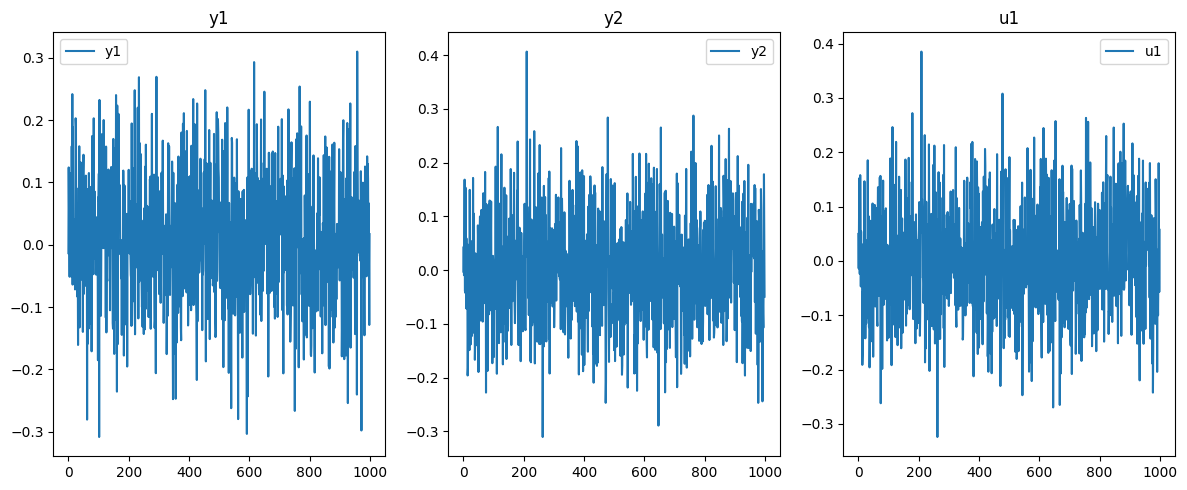

In [14]:
def simulate_Narx2(n_points,sigma_noise,seed=42):

    np.random.seed(seed) # pour la reproductibilité

    # génération de U (deux colonnes cette fois ci u1 et u2)
    U_Narx2 = pd.DataFrame(np.zeros((n_points+3,2)),columns=['u1', 'u2'])
    Y_Narx2 = pd.DataFrame(np.zeros((n_points+3,2)),columns=['y1', 'y2'])
    # générer U qui suit une distribution normale (moyenne 0, écart-type 0.1) : mon choix
    # arbitraire. Pour le coupp si je mets une trop grand evariance il y a explosion des données
    U_Narx2.loc[3:,'u1'] = np.random.normal(0, 0.1, size=n_points)
    U_Narx2.loc[3:,'u2'] = np.random.normal(0, 0.1, size=n_points)
    # n+1 points car on a u-1 qui doit être défini pour générer y1_1 et y2_1 :
    # on change sa valeur en 0 après
    # pa rapport à la génération de Y, pas besoin de remonter à u-2 (cf formules)
    #U_Narx2.loc[0, 'u1'] = 0 # pour respecter l'énoncé =u-1 = 0
    #U_Narx2.loc[1, 'u1'] = 0 # u0 = 0
    #U_Narx2.loc[0, 'u2'] = 0 # pour respecter l'énoncé =u-1 = 0
    #U_Narx2.loc[1, 'u2'] = 0 # u0 = 0
    
    print(U_Narx2.head())
    print("shape U", U_Narx2.shape)
    
    
    # génération de Y
    # y1_0 = 0, y2_0 = 0 # cf énoncé : je me mets dans le m^me cas que les données réelles
    # à prédire (exo principal du projet)
    y1_0 = 0
    y2_0 = 0
    # y-1 = 0, y-2 = 0 # cf énoncé, nécessaire pour générer y1_1 et y2_1
    y1_minus_1 = 0
    y2_minus_1 = 0
    y1_minus_2 = 0
    y2_minus_2 = 0
    Y_Narx2.loc[0] = [y1_minus_2, y2_minus_2]
    Y_Narx2.loc[1] = [y1_minus_1, y2_minus_1]
    Y_Narx2.loc[2] = [y1_0, y2_0]
    # Bien faire attention à supprimer les 2 lignes à la fin et pas une seule
    # il faudra peut être les rajouter pour nos stratégies dans le futur (dépend de à quel point on souhaite
    # regarder le futur)

    
    for k in range(2, n_points+2): # on est décalé à 2 car on a ajouter y-1
        # les indices seront réglés après la boucle
        # deux formules données dans l'énoncé
    
        y1_k = Y_Narx2.loc[k, 'y1']
        y1_km1 = Y_Narx2.loc[k-1, 'y1']
        y1_km2 = Y_Narx2.loc[k-2, 'y1']
    
        y2_k = Y_Narx2.loc[k, 'y2']
        y2_km1 = Y_Narx2.loc[k-1, 'y2']
        y2_km2 = Y_Narx2.loc[k-2, 'y2']
    
        u1_k = U_Narx2.loc[k, 'u1']
        u1_km1 = U_Narx2.loc[k-1, 'u1']
    
        u2_k = U_Narx2.loc[k, 'u2']
        u2_km1 = U_Narx2.loc[k-1, 'u2']
    
        # Génération du bruit blanc w
        w1 = np.random.normal(0, sigma_noise)
        w2 = np.random.normal(0, sigma_noise)
    
        # Formule pour y1(k+1)
        num1 = y1_k * y1_km1 * y1_km2 * (y1_km2 - 1) * u2_km1 + u2_k
        den1 = 1 + y2_km1**2 + y2_km2**2
        y1_plus1 = (num1 / den1) + w1
    
        # Formule pour y2(k+1)
        num2 = y2_k * y2_km1 * y2_km2 * (y2_km2 - 1) * u1_km1 + u1_k
        den2 = 1 + y1_km1**2 + y1_km2**2
        y2_plus1 = (num2 / den2) + w2
    
        # Stockage du résultat à l'indice k+1
        Y_Narx2.loc[k+1] = [y1_plus1, y2_plus1]

    # enlever la première ligne qui correspond à y-1 et y-2 et u-1 qui ont servi à générer les données
    Y_Narx2 = Y_Narx2.drop(index=2).reset_index(drop=True)
    Y_Narx2 = Y_Narx2.drop(index=1).reset_index(drop=True)
    Y_Narx2 = Y_Narx2.drop(index=0).reset_index(drop=True)
    U_Narx2 = U_Narx2.drop(index=2).reset_index(drop=True)
    U_Narx2 = U_Narx2.drop(index=1).reset_index(drop=True)
    U_Narx2 = U_Narx2.drop(index=0).reset_index(drop=True)
    return U_Narx2, Y_Narx2
#fait la simu    
sigma2=0 #0.02
U_Narx2, Y_Narx2 = simulate_Narx2(n_points, sigma2)

print(Y_Narx2.head(15))
print("shape Y", Y_Narx2.shape)
print("shape U", U_Narx2.shape)

# visualiser les données générées
figure, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].plot(Y_Narx2['y1'], label='y1')
axes[0].set_title('y1')
axes[0].legend()
axes[1].plot(Y_Narx2['y2'], label='y2')
axes[1].set_title('y2')
axes[1].legend()
axes[2].plot(U_Narx2['u1'], label='u1')
axes[2].set_title('u1')
axes[2].legend()
plt.tight_layout()
plt.show()


On a des données très très bruitées .... Utiliser des pilotes très bruités

- Test de nos pilotes : en connaissant la formule de génération qui est linéaire pour Narx1
De plus, pour NArx1, le modèle est linéaire en ses coefficients

On prépare déjà les dataframes, et les jeux de données de tests et train. 
C'est une question qui peut être intéressante à discuter : comment séparer les trains tests ...
J'ai codé 2 méthodes pour faire ça : 
1 méthode qui sépare chronoogiquement les données et une autre qui sépare de manière alternée (peut être plus judicieux poir avoir pls échantillons de val)



In [15]:
# regression linéaire sur NArx1
U_Narx1_reg = pd.DataFrame()
U_Narx1_reg['u'] = U_Narx1['u']
U_Narx1_reg['u_lag1'] = U_Narx1['u'].shift(1) # décalge vers le bas
U_Narx1_reg['u_lag2'] = U_Narx1['u'].shift(2)
U_Narx1_reg['y1_lag1'] = Y_Narx1['y1'].shift(1)
U_Narx1_reg['y1_lag2'] = Y_Narx1['y1'].shift(2)
U_Narx1_reg['y2_lag1'] = Y_Narx1['y2'].shift(1)
U_Narx1_reg['y2_lag2'] = Y_Narx1['y2'].shift(2)
# cf énoncé, les conditions initiales avant l'instant 0 sont nulles

U_Narx1_reg = U_Narx1_reg.fillna(0)

print(U_Narx1_reg.head())
print(Y_Narx1.head())
print("shape U", U_Narx1_reg.shape)


Y_Narx1_reg = pd.DataFrame()
Y_Narx1_reg['y1'] = Y_Narx1['y1'].shift(-1)  # décalage vers le haut pour faire correspondre
Y_Narx1_reg['y2'] = Y_Narx1['y2'].shift(-1) # y1(k+1) avec la bonne ligne de feautures
# afficher la fin du dataframe pour vérifier que le décalage a fonctionné
print(Y_Narx1_reg.tail())
print("shape Y", Y_Narx1_reg.shape)
# dernière ligne de Y est des NA car on a décalé vers le haut, on la supprime car on ne peut
# pas faire de prédiction pour cette ligne. On l'enelve aussi dans U pour garder les mêmes dimensions
Y_Narx1_reg = Y_Narx1_reg.drop(index=Y_Narx1_reg.index[-1]).reset_index(drop=True)
U_Narx1_reg = U_Narx1_reg.drop(index=U_Narx1_reg.index[-1]).reset_index(drop=True)

print(Y_Narx1_reg.tail())
print("shape final Y", Y_Narx1_reg.shape)
print("shape final U", U_Narx1_reg.shape)

# séparation des données en train et test

def split_train_val(X, Y, methode="chronologique", val_size=0.2, train_size_alt=50, val_size_alt=10):
    """
    Split les données en train et val selon la méthode choisie.
    - méthode chronologique : les données de train sont les premières lignes du dataframe, les données de val sont les dernières lignes du dataframe
    - méthode alternée : les données de train et de val sont alternées dans le dataframe, on choisit le nombre de samples de val que l'on veut (ex : 5)
    """
    if methode == "chronologique":
        n_train = int(len(X) * (1 - val_size))
        X_train = X.iloc[:n_train]
        Y_train = Y.iloc[:n_train]
        X_val = X.iloc[n_train:]
        Y_val = Y.iloc[n_train:]

    elif methode == "alternee":
        X_train = []
        Y_train = []
        X_val = []
        Y_val = []
        i = 0
        verif_nb_samples = train_size_alt + val_size_alt # pour avoir des blocs complets de train et val
        while verif_nb_samples <= len(X):
            X_train.append(X.iloc[i:i+train_size_alt])
            Y_train.append(Y.iloc[i:i+train_size_alt])
            X_val.append(X.iloc[i+train_size_alt:i+train_size_alt+val_size_alt])
            Y_val.append(Y.iloc[i+train_size_alt:i+train_size_alt+val_size_alt])
            i += train_size_alt + val_size_alt
            verif_nb_samples += train_size_alt + val_size_alt

    return X_train, Y_train, X_val, Y_val

print("split chronologique")
X_train_chrono, Y_train_chrono, X_val_chrono, Y_val_chrono = split_train_val(U_Narx1_reg, Y_Narx1_reg, methode="chronologique", val_size=0.2)
print("Shape : ", X_train_chrono.shape, Y_train_chrono.shape, X_val_chrono.shape, Y_val_chrono.shape)
print("split alterné")
X_train_alterne, Y_train_alterne, X_val_alterne, Y_val_alterne = split_train_val(U_Narx1_reg, Y_Narx1_reg, methode="alternee", train_size_alt=50, val_size_alt=10)
print("Shape : ", X_train_alterne[-1].shape, Y_train_alterne[-1].shape, X_val_alterne[-1].shape, Y_val_alterne[-1].shape)

          u    u_lag1    u_lag2   y1_lag1  y1_lag2   y2_lag1   y2_lag2
0  0.993428  0.000000  0.000000  0.000000  0.00000  0.000000  0.000000
1 -0.276529  0.993428  0.000000  0.000000  0.00000  0.000000  0.000000
2  1.295377 -0.276529  0.993428  0.000000  0.00000  0.198686  0.000000
3  3.046060  1.295377 -0.276529  0.495410  0.00000 -0.055306  0.198686
4 -0.468307  3.046060  1.295377 -0.038893  0.49541  0.734467 -0.055306
         y1        y2
0  0.000000  0.000000
1  0.000000  0.198686
2  0.495410 -0.055306
3 -0.038893  0.734467
4  1.031152  0.818033
shape U (1000, 7)
           y1        y2
995  0.812532  1.516135
996  1.300166  2.123938
997  2.687557  1.626205
998  2.444940  0.860207
999       NaN       NaN
shape Y (1000, 2)
           y1        y2
994  1.357667  0.940639
995  0.812532  1.516135
996  1.300166  2.123938
997  2.687557  1.626205
998  2.444940  0.860207
shape final Y (999, 2)
shape final U (999, 7)
split chronologique
Shape :  (799, 7) (799, 2) (200, 7) (200, 2)
split a

alignement k -> k+1 pour avoir dynamique temporell en matrice de régression statique (ainsi modèle ne voit pas réponse avant de prédire)

- Travail rapide, pas spécialement important, donne une brève idée 

- Analyse en vif, très vif sur les vrais données

On regarde corrélation entre les entrées et leurs retards. Cela nous permet de voir si deux u_lag sont corrélés alors le modèle n'a peut être pas besoin des 2.


In [16]:
# calculer la corrélation entre les différentes variables
df_total = pd.concat([X], axis=1)
correlation_matrix_total = df_total.corr()
print("Correlation matrix:\n", correlation_matrix_total)

Correlation matrix:
          Utr0     Utr1
Utr0  1.00000 -0.16708
Utr1 -0.16708  1.00000


Les coefficients ne sont pas si élevés que ca ... la régression linéaire sur ces variables explicatives semblent compromis

On use une filter method. Cela nous permet d'évaluer les features indépendamment de l'algorithme de train final. 
On va use le Ranking avec la corrélation de Pearson (Cela nous permet de selectionner les caractéristiques en voyant l'importante de chaque variabke par rapport à la sortie en supossant que relation linéaire). De plus, c'est une technique rapide et efficace car une complexité de O(n) . 

Correlation matrix:
                 u    u_lag1    u_lag2   y1_lag1   y1_lag2   y2_lag1   y2_lag2  \
u        1.000000 -0.007150 -0.000599 -0.009513 -0.038526  0.008575 -0.005305   
u_lag1  -0.007150  1.000000 -0.006769 -0.007590 -0.009780 -0.036184  0.009098   
u_lag2  -0.000599 -0.006769  1.000000 -0.008116 -0.007156  0.671147 -0.036527   
y1_lag1 -0.009513 -0.007590 -0.008116  1.000000  0.339056  0.123425  0.698130   
y1_lag2 -0.038526 -0.009780 -0.007156  0.339056  1.000000  0.240577  0.130313   
y2_lag1  0.008575 -0.036184  0.671147  0.123425  0.240577  1.000000  0.175620   
y2_lag2 -0.005305  0.009098 -0.036527  0.698130  0.130313  0.175620  1.000000   
y1      -0.007975  0.819532  0.274974  0.127947  0.122423  0.453433  0.155135   
y2       0.676504 -0.007398 -0.040621  0.581124  0.219098  0.149333  0.398152   

               y1        y2  
u       -0.007975  0.676504  
u_lag1   0.819532 -0.007398  
u_lag2   0.274974 -0.040621  
y1_lag1  0.127947  0.581124  
y1_lag2  0.122423 

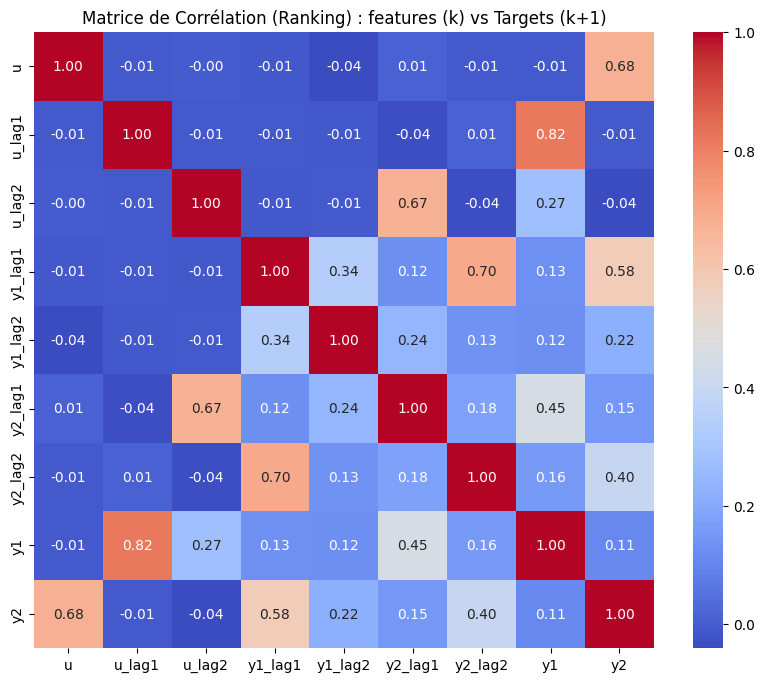

In [17]:
import seaborn as sns
# concaténation feature et cibles
df_analyse = pd.concat([U_Narx1_reg,Y_Narx1_reg], axis=1) #concaténation pour évaluer pertinence par rapport aux cibles
correlation_matrix = df_analyse.corr() #Corrélation de Pearson
print("Correlation matrix:\n", correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation (Ranking) : features (k) vs Targets (k+1)")
plt.show()

- on voit que y1 et y2 sont très corrélés (orange/rouge en bas à droite) -> très couplé
- **Tache 2 a)** on voit que corrélations pour lag2 plutôt élevées (0,6~0,7) donc cela nous permet de voir que l'information à lag2 (y(k-1)) impacte beaucoup à cible (y(k+1)). Il y a 2 pas d'écart entre cible et lag 2 et la corrélation reste forte malgré les deux pas d'écart donc na=2. Avec na=2, on dit au modèle que il faut utiliser y(k) et y(k-1) et donc le modèle aura plus de faciliter à réduire MSE.

Interressant de regarder lag 3 

Correlation matrix avec lag3:
                 u    u_lag1    u_lag2   y1_lag1   y1_lag2   y2_lag1   y2_lag2  \
u        1.000000 -0.007150 -0.000599 -0.009513 -0.038526  0.008575 -0.005305   
u_lag1  -0.007150  1.000000 -0.006769 -0.007590 -0.009780 -0.036184  0.009098   
u_lag2  -0.000599 -0.006769  1.000000 -0.008116 -0.007156  0.671147 -0.036527   
y1_lag1 -0.009513 -0.007590 -0.008116  1.000000  0.339056  0.123425  0.698130   
y1_lag2 -0.038526 -0.009780 -0.007156  0.339056  1.000000  0.240577  0.130313   
y2_lag1  0.008575 -0.036184  0.671147  0.123425  0.240577  1.000000  0.175620   
y2_lag2 -0.005305  0.009098 -0.036527  0.698130  0.130313  0.175620  1.000000   
u_lag3   0.015160  0.000500 -0.007940  0.813743 -0.007017 -0.006308  0.668307   
y1_lag3  0.033042 -0.039181 -0.008878  0.142344  0.342932  0.587463  0.247426   
y2_lag3 -0.036411 -0.005363  0.009259  0.461722  0.700285  0.164445  0.182515   
y1      -0.007975  0.819532  0.274974  0.127947  0.122423  0.453433  0.155135 

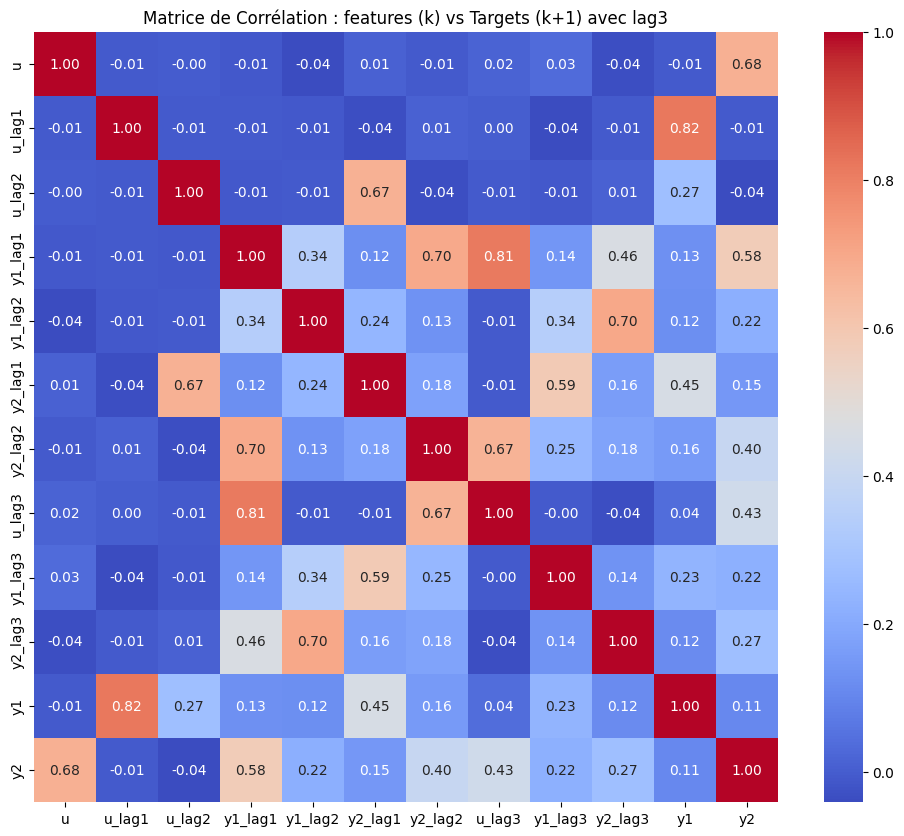

In [18]:
U_Narx1_reg['u_lag3'] = U_Narx1['u'].shift(3)
U_Narx1_reg['y1_lag3'] = Y_Narx1['y1'].shift(3)
U_Narx1_reg['y2_lag3'] = Y_Narx1['y2'].shift(3)

U_Narx1_reg = U_Narx1_reg.fillna(0)

df_analyse_lag3 = pd.concat([U_Narx1_reg,Y_Narx1_reg], axis=1)
correlation_matrix_lag3 = df_analyse_lag3.corr()
print("Correlation matrix avec lag3:\n", correlation_matrix_lag3)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_lag3, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation : features (k) vs Targets (k+1) avec lag3")
plt.show()

Avec Lag 3 on peut voir que l'on a eu une corrélation qui stagne. La différence entre lag 2 et lag 3 est minime donc on conserve **na=2**. Cela nous évite de rendre trop complexe le modèle. 

Donc pour éviter curse of dimensionality, on sélectionne le sous-ensemble {u, u_lag1, u_lag2, y1_lag1, y1_lag2 ...} car maximise sans ajouter de variables inutiles.

Wrapper

In [19]:
X_val = X[800:1000]
Y_val = Y[800:1000]
X_train = X[:800]
Y_train = Y[:800]
    

100%|███████████████████████████████████████████████| 2/2 [00:00<00:00, 68.40it/s]


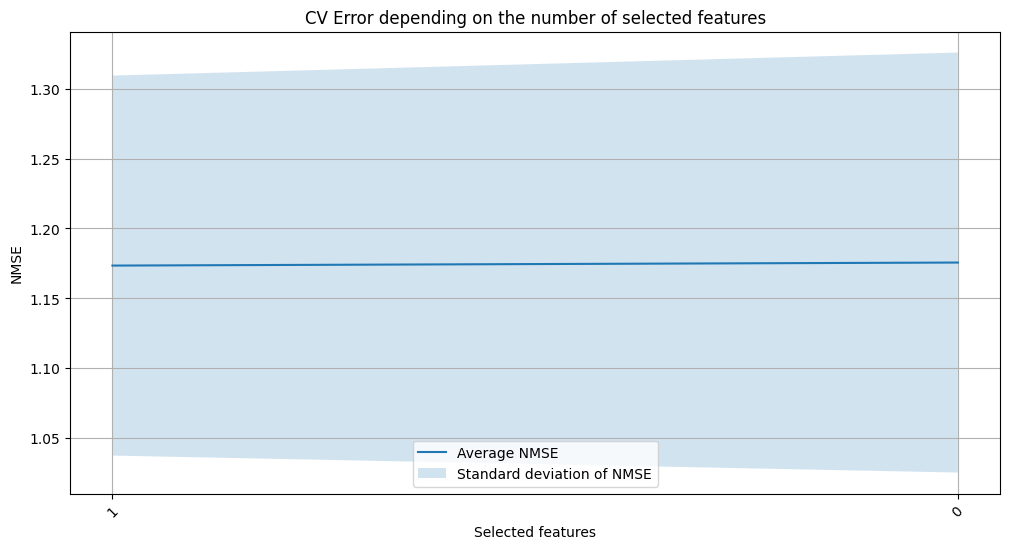

In [20]:
from tqdm import tqdm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

#calcule de NMSE
def nmse(y_original,y_pred):
    mse=mean_squared_error(y_original,y_pred)
    variance=np.var(y_original)
    return mse/variance

#wrapper initialization
selected=[] #indices des variables retenues
CV_err=[] #evolution de erreur moyyenne de cross validation
std_err=[] #evolution ecart type
n=X_train.shape[1]
feature_name=list(X_train.columns)

kf=TimeSeriesSplit(n_splits=5) #pour ne pas mélanger les données car temporelles

#utilise le bloc train pour cross validation
X_fs=X_train
Y_fs=Y_train["Ytr0"].values

#boucle Forward selection (greedy)
for round_i in tqdm(range(n)):
    candidates=list(set(range(n))-set(selected))
    CV_err_temp=[]
    round_fold_errors=[] #permet de stocker les erreurs de chaque fold par candidat
    
    for c in candidates:
        features_to_include=selected+[c] #on teste ensemble actuel avec un new candidat
        fold_errors=[]

        #cross validation intern sur 5 périodes dif
        for train_index, test_index in kf.split(X_fs):
            X_tr,X_ts=X_fs.iloc[train_index, features_to_include],X_fs.iloc[test_index, features_to_include] #spéaration train et test
            Y_tr,Y_ts=Y_fs[train_index],Y_fs[test_index]

            #baseline
            model = LinearRegression()
            model.fit(X_tr,Y_tr)
            #prediction
            Y_hat_ts=model.predict(X_ts)
            fold_errors.append(nmse(Y_ts,Y_hat_ts))
        #moyenne des erreurs    
        CV_err_temp.append(np.mean(fold_errors))
        round_fold_errors.append(fold_errors)
        
#selection meilleur candidat
    best_index=np.argmin(CV_err_temp)
    best_candidate=candidates[best_index]
    
    selected.append(best_candidate)
    CV_err.append(CV_err_temp[best_index])
    std_err.append(np.std(round_fold_errors[best_index]))

x=list(range(1,n+1))
errors=np.array(CV_err)
stds=np.array(std_err)
labels=[feature_name[i] for i in selected]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, errors, label="Average NMSE")
ax.fill_between(x, errors - stds, errors + stds, alpha=0.2, label="Standard deviation of NMSE")
ax.set_title("CV Error depending on the number of selected features")
ax.set_xlabel("Selected features")
ax.set_ylabel("NMSE")
ax.set_xticks(ticks=x, labels=selected, rotation=45)
plt.legend()
plt.grid("on")
plt.show()
    

- **REGRESSION LINEAIRE**

On va d'abord faire une régression linéaire en utilisant simplement les valeurs de u1 et u2 pour prédire y. On s'attend cependant à des résultats plutôt moyen 

In [ ]:


model = LinearRegression()
model.fit(X_train, Y_train["Ytr0"])
Y_pred = model.predict(X_val)
mse = mean_squared_error(Y_val["Ytr0"], Y_pred)
print("Mean Squared Error:", mse)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# erreur si on prédit la valeur moyenne de Ytr0
mean_prediction = np.mean(Y_train["Ytr0"])
mean_mse = mean_squared_error(Y_val["Ytr0"], [mean_prediction] * len(Y_val))
print("Mean Prediction MSE:", mean_mse)


# affichage des résultats
plt.figure(figsize=(10, 6))
plt.plot(Y_val["Ytr0"].values, label='True Values', marker='o')
plt.plot(Y_pred, label='Predicted Values', marker='x')
plt.title('True vs Predicted Values for Ytr0')
plt.xlabel('Sample Index')
plt.ylabel('Ytr0 Value')
plt.legend()
plt.grid()
plt.show()

On voit bien en comparant le mse d'un modèle qui prédit la moyenne de Ytr0 que le modèle 
de régression linéaire uniquement sur l'instant t

In [ ]:
X["Utr0_lag1"] = X["Utr0"].shift(1)
X["Utr1_lag1"] = X["Utr1"].shift(1)
X["Ytr0_lag1"] = Y["Ytr0"].shift(1)
X["Ytr1_lag1"] = Y["Ytr1"].shift(1)
X["Utr0_lag2"] = X["Utr0"].shift(2)
X["Utr1_lag2"] = X["Utr1"].shift(2)
X["Ytr0_lag2"] = Y["Ytr0"].shift(2)
X["Ytr1_lag2"] = Y["Ytr1"].shift(2)
X["Utr0_lag3"] = X["Utr0"].shift(3)
X["Utr1_lag3"] = X["Utr1"].shift(3)
X["Ytr0_lag3"] = Y["Ytr0"].shift(3)
X["Ytr1_lag3"] = Y["Ytr1"].shift(3)
X = X.dropna()
Y = Y.loc[X.index] # le dropna a supprimé les 3 premières lignes et n'a pas modifié les index
X_val = X[800:1000]
Y_val = Y[800:1000]
X_train = X[:800]
Y_train = Y[:800]
model = LinearRegression()
model.fit(X_train, Y_train["Ytr0"])
Y_pred = model.predict(X_val)
mse = mean_squared_error(Y_val["Ytr0"], Y_pred)
print("Mean Squared Error with lags:", mse)


Le problème c'est que là je connais le futur donc j'utilise les données réelles pour yk-1, etc et non les données prédites ... Cela evite l'effet boule de neige mais ce ne sera pas le cas en vrai ...

In [ ]:
# utiliser sa propre prédiction comme entrée pour les prédictions futures
Y_pred_future = []
current_input = X_val.iloc[0].copy() # copy pour ne pas modifier X_val
for i in range(len(X_val)):
    pred = model.predict(current_input.values.reshape(1, -1))[0]
    Y_pred_future.append(pred)
    current_input["Ytr0_lag1"] = pred
    current_input["Ytr0_lag2"] = current_input["Ytr0_lag1"]
    current_input["Ytr0_lag3"] = current_input["Ytr0_lag2"]
    current_input["Utr0_lag1"] = current_input["Utr0"]
    current_input["Utr1_lag1"] = current_input["Utr1"]
    current_input["Utr0_lag2"] = current_input["Utr0_lag1"]
    current_input["Utr1_lag2"] = current_input["Utr1_lag1"]
    current_input["Utr0_lag3"] = current_input["Utr0_lag2"]
    current_input["Utr1_lag3"] = current_input["Utr1_lag2"]
mse_future = mean_squared_error(Y_val["Ytr0"], Y_pred_future)
print("Mean Squared Error with future predictions:", mse_future)